# IPL 2026 Winner Prediction – Analysis Notebook

This notebook walks through the complete analysis pipeline:
1. Data exploration
2. Feature distributions
3. Model comparison
4. Final 2026 predictions

In [1]:
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

from config import FEATURES_CSV, PROCESSED_MATCHES_CSV, RESULTS_DIR, TEAMS

## 1. Load Data

In [2]:
matches = pd.read_csv(PROCESSED_MATCHES_CSV)
features = pd.read_csv(FEATURES_CSV)
print(f'Matches: {len(matches)} rows')
print(f'Features: {len(features)} rows × {len(features.columns)} cols')
matches.head()

Matches: 2264 rows
Features: 2264 rows × 36 cols


,match_id,season,team1,team2,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,venue,city,stage,team1_won,toss_won_by_team1,toss_decision_bat
0,-58,2008,RR,CSK,RR,field,RR,0,3,Dr DY Patil Sports Academy,Mumbai,Final,1,1,0
1,-57,2008,CSK,PBKS,PBKS,bat,CSK,0,9,Wankhede Stadium,Mumbai,Semi Final,1,0,1
2,-56,2008,DC,RR,DC,field,RR,105,0,Wankhede Stadium,Mumbai,Semi Final,0,1,0
3,-55,2008,RR,PBKS,RR,field,PBKS,41,0,"Punjab Cricket Association Stadium, Mohali",Chandigarh,Unknown,0,1,0
4,-54,2008,MI,RCB,MI,field,MI,0,9,M Chinnaswamy Stadium,Bangalore,Unknown,1,1,0


## 2. Matches Per Season

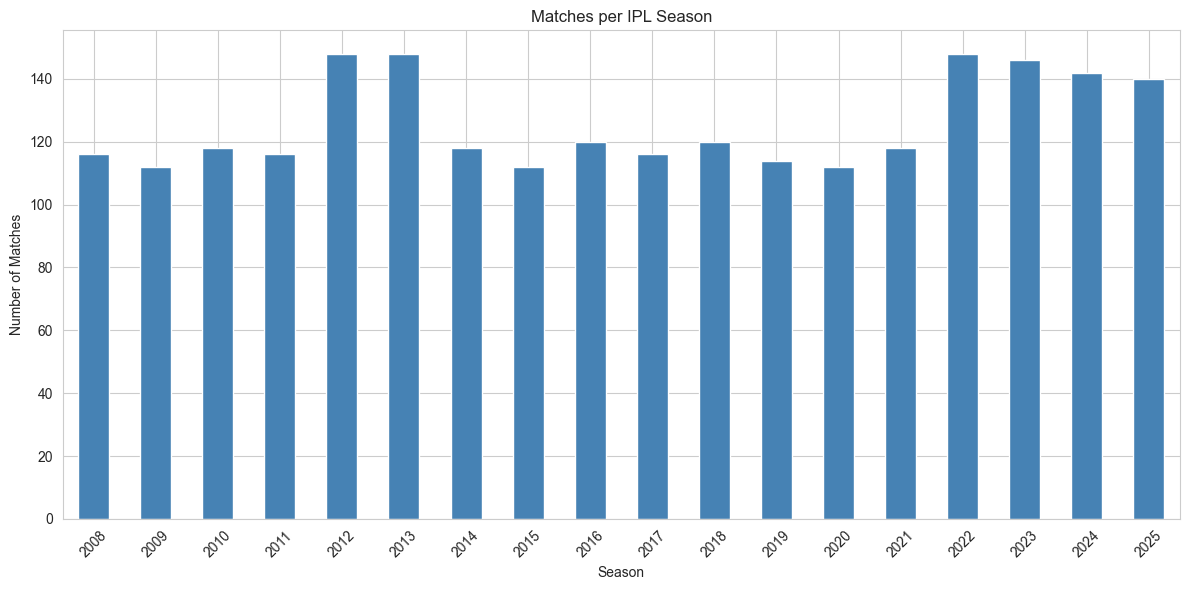

In [3]:
season_counts = matches.groupby('season').size()
season_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Matches per IPL Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. All-Time Win Rates

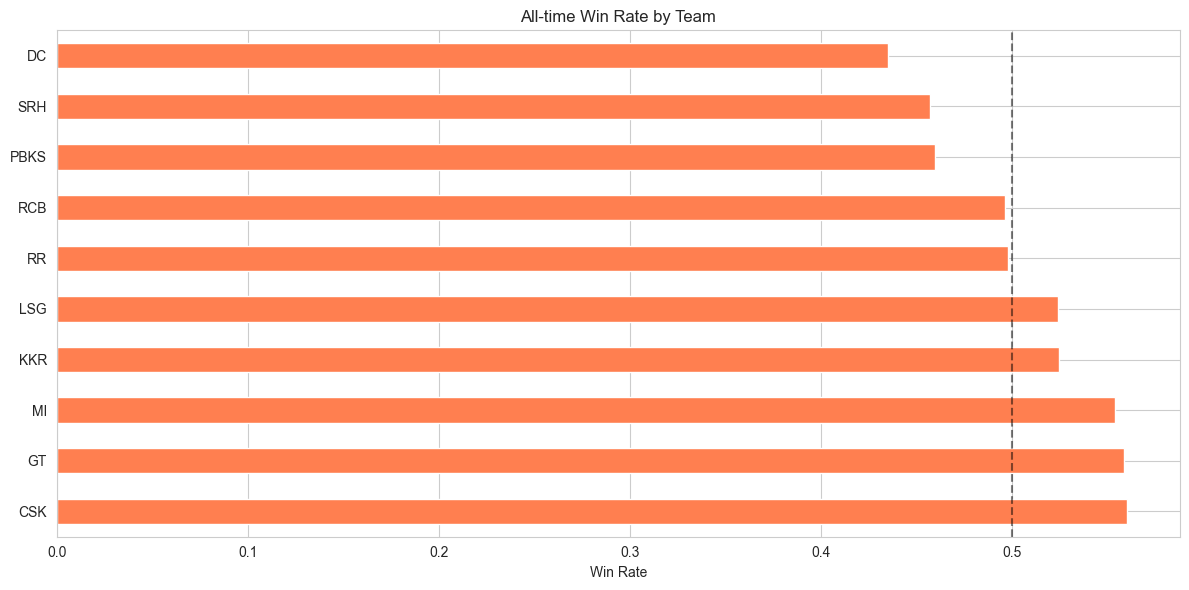

CSK     0.560071
GT      0.558511
MI      0.554152
KKR     0.524809
LSG     0.524194
RR      0.497845
RCB     0.496255
PBKS    0.459924
SRH     0.457407
DC      0.435000
dtype: float64

In [4]:
from src.features.engineer import get_all_time_win_rates
win_rates = get_all_time_win_rates(matches)
active = {k: v for k, v in win_rates.items() if k in TEAMS}
sr = pd.Series(active).sort_values(ascending=False)
sr.plot(kind='barh', color='coral', edgecolor='white')
plt.title('All-time Win Rate by Team')
plt.xlabel('Win Rate')
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
sr

## 4. Feature Correlation Heatmap

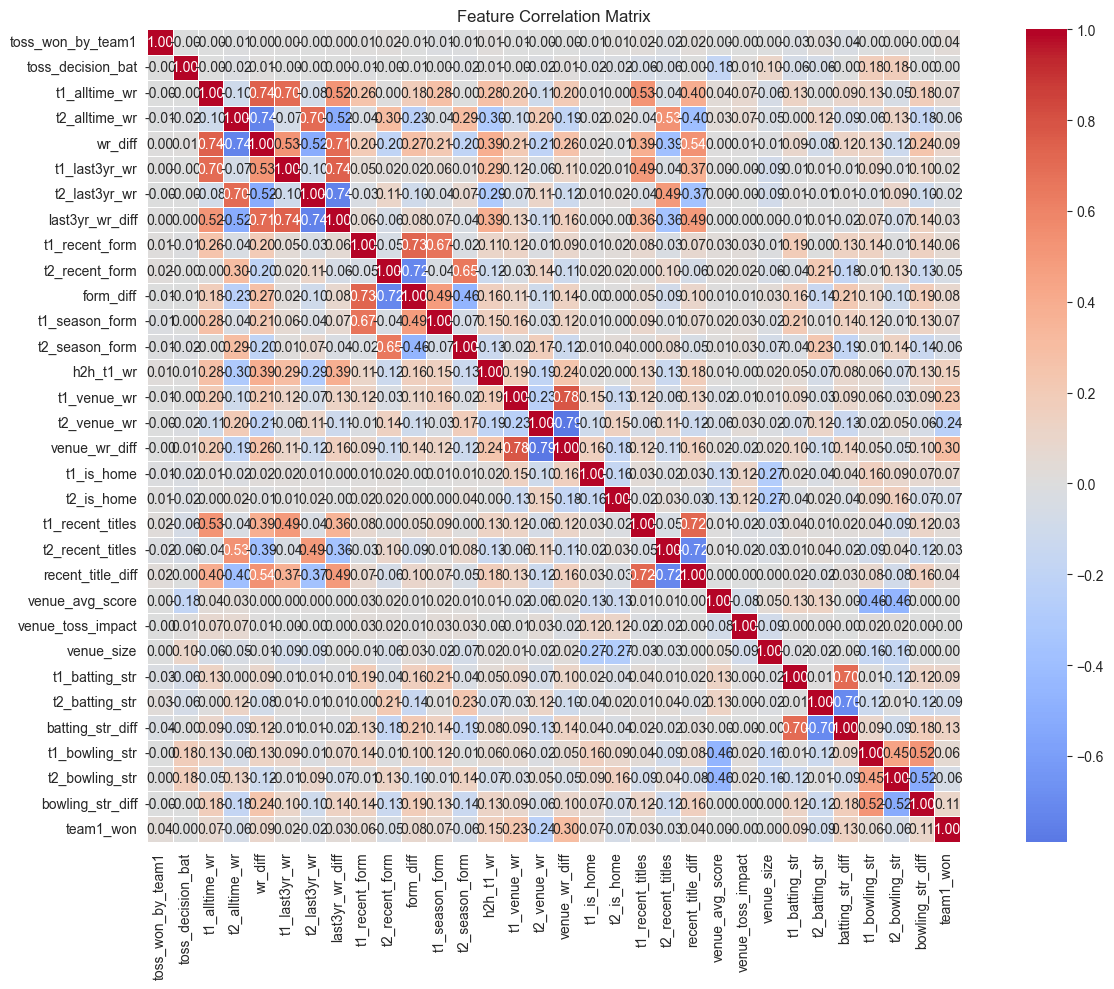

In [5]:
from src.models.base_model import FEATURE_COLS
corr = features[FEATURE_COLS + ['team1_won']].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 5. Toss Analysis

Toss winner also wins match: 51.8%


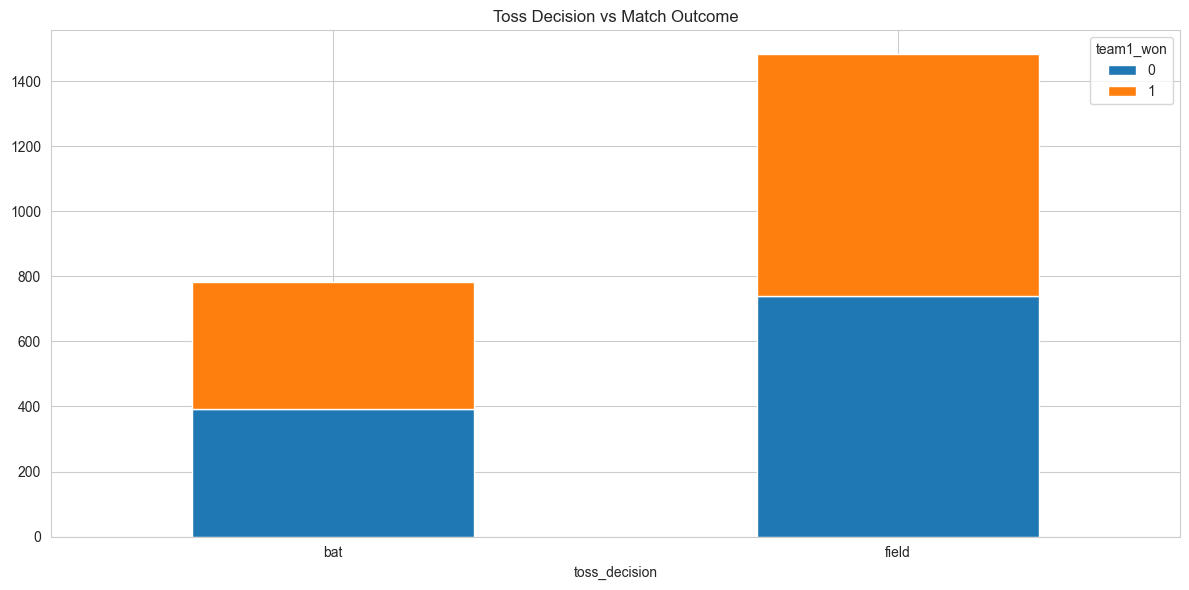

In [6]:
toss_win_rate = matches[matches['toss_winner'] == matches['winner']].shape[0] / len(matches)
print(f'Toss winner also wins match: {toss_win_rate:.1%}')

toss_dec = matches.groupby(['toss_decision', 'team1_won']).size().unstack()
toss_dec.plot(kind='bar', stacked=True)
plt.title('Toss Decision vs Match Outcome')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Model Performance Comparison

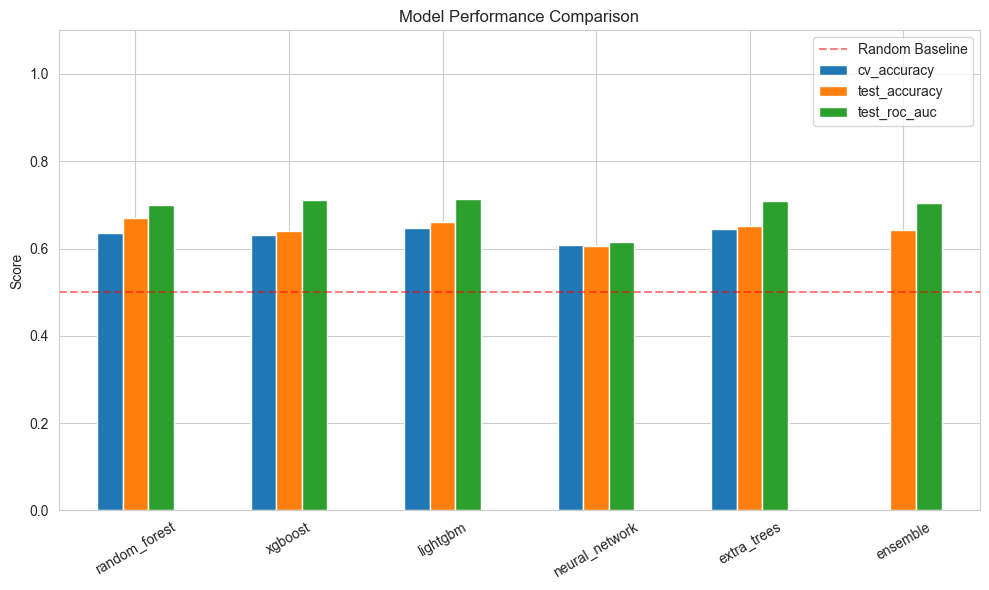

,cv_accuracy,cv_std,train_accuracy,test_accuracy,test_roc_auc
random_forest,0.6350,0.0138,0.9531,0.6711,0.6995
xgboost,0.6300,0.0124,0.9994,0.6402,0.7120
lightgbm,0.6477,0.0102,0.9978,0.6600,0.7138
neural_network,0.6080,0.0127,0.9845,0.6049,0.6141
extra_trees,0.6444,0.0060,0.9862,0.6512,0.7083
ensemble,NaN,NaN,1.0000,0.6424,0.7049


In [7]:
results_path = os.path.join(RESULTS_DIR, 'model_results.json')
with open(results_path) as f:
    results = json.load(f)

df_res = pd.DataFrame(results).T
df_res[['cv_accuracy', 'test_accuracy', 'test_roc_auc']].plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
plt.legend()
plt.tight_layout()
plt.show()

df_res

## 7. IPL 2026 Prediction Results

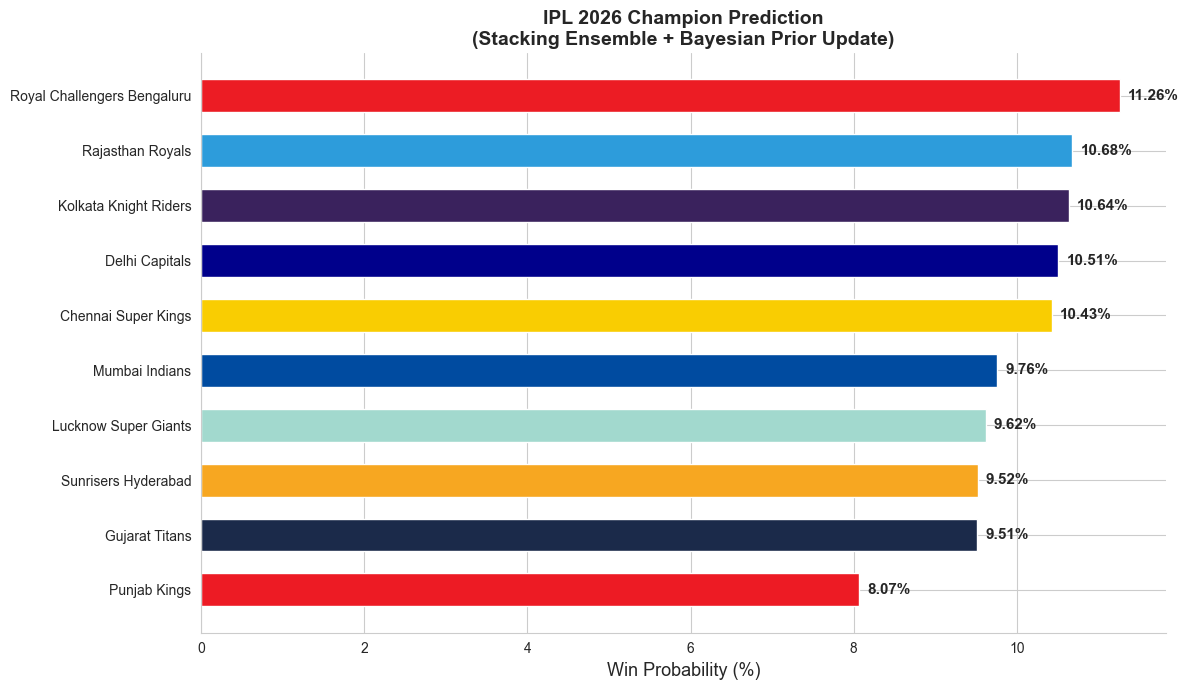


🏆 Predicted IPL 2026 Winner: Royal Challengers Bengaluru
   Win probability: 11.26%


In [8]:
pred_path = os.path.join(RESULTS_DIR, 'prediction_2026.json')
with open(pred_path) as f:
    pred_data = json.load(f)

rankings = pred_data['rankings']
df_pred = pd.DataFrame(rankings).set_index('rank')

PALETTE = {
    'CSK': '#F9CD02', 'MI': '#004BA0', 'RCB': '#EC1C24', 'KKR': '#3A225D',
    'DC': '#00008B', 'PBKS': '#ED1B24', 'RR': '#2D9CDB', 'SRH': '#F7A721',
    'LSG': '#A2D9CE', 'GT': '#1B2A4A',
}

fig, ax = plt.subplots(figsize=(12, 7))
teams = [r['team_name'] for r in rankings]
probs = [r['win_probability'] for r in rankings]
colors = [PALETTE.get(r['team_id'], '#888') for r in rankings]

bars = ax.barh(teams[::-1], probs[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for bar, prob in zip(bars, probs[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{prob:.2f}%', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Win Probability (%)', fontsize=13)
ax.set_title('IPL 2026 Champion Prediction\n(Stacking Ensemble + Bayesian Prior Update)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n🏆 Predicted IPL 2026 Winner: {rankings[0]['team_name']}")
print(f"   Win probability: {rankings[0]['win_probability']:.2f}%")